# 🧠 Module 2 – Session 1 Assignment
# Investigating Attention in BERT

**Course:** Generative & Agentic AI Systems

## Objective
In this assignment you will investigate how BERT distributes attention across different linguistic phenomena.

Rather than proving *how BERT thinks*, your goal is to collect evidence and make engineering observations.

---
## Learning Outcomes
After completing this notebook you should be able to:

- Build linguistic probes
- Visualize attention using BertViz
- Identify interesting attention heads
- Compare expectations with observations
- Write an engineering conclusion


# Part 0 – Environment

In [ ]:
# Uncomment if needed
# !pip install transformers bertviz torch

In [1]:
from transformers import AutoTokenizer, AutoModel
import torch

MODEL_NAME="bert-base-uncased"

tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME)
model=AutoModel.from_pretrained(MODEL_NAME,output_attentions=True)
model.eval()

print("Model Loaded Successfully")

d:\anaconda\envs\ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6441.42it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task

Model Loaded Successfully


In [2]:
def get_attention(sentence):
    inputs=tokenizer(sentence,return_tensors="pt")
    with torch.no_grad():
        outputs=model(**inputs)

    tokens=tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    return tokens,outputs.attentions

# Part 1 – Build Your Test Set (15 Marks)

Create **5 sentences**.

| Sentence Type | Your Sentence | Expected Attention |
|---------------|---------------|--------------------|
| Long Dependency |The boy who plays football every weekend is my friend. |Between boy and friend |
| Ambiguous Pronoun |Ali told Omar that he was late. |On he and the names |
| Negation | I do not like coffee.|On not and like |
| Passive Voice |The cake was baked by my mother. |Between baked and mother |
| Free Choice |Anyone can enter the room. |On Anyone |

**Questions**

1. Why did you choose these sentences?
- *I chose these sentences because they are simple and each one tests a different language case.*
2. What do you expect BERT to focus on?
- *I expect BERT to focus on important words like names, verbs, and not.*


# Part 2 – Run Your Experiments

In [3]:
# Replace with one of your own sentences

sentence="The boy who plays football every weekend is my friend."

tokens,attentions=get_attention(sentence)

print(tokens)
print("Layers:",len(attentions))
print("Heads:",attentions[0].shape[1])

['[CLS]', 'the', 'boy', 'who', 'plays', 'football', 'every', 'weekend', 'is', 'my', 'friend', '.', '[SEP]']
Layers: 12
Heads: 12


In [4]:
# TODO

from bertviz import head_view
head_view(attentions,tokens)

#Take a screenshot and paste it below.


<IPython.core.display.Javascript object>

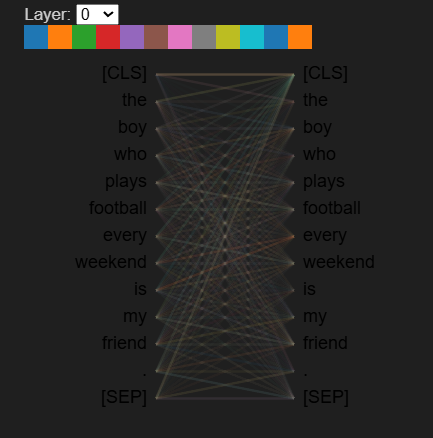

In [5]:
# TODO

from bertviz import model_view
model_view(attentions,tokens)

# Take another screenshot.


<IPython.core.display.Javascript object>

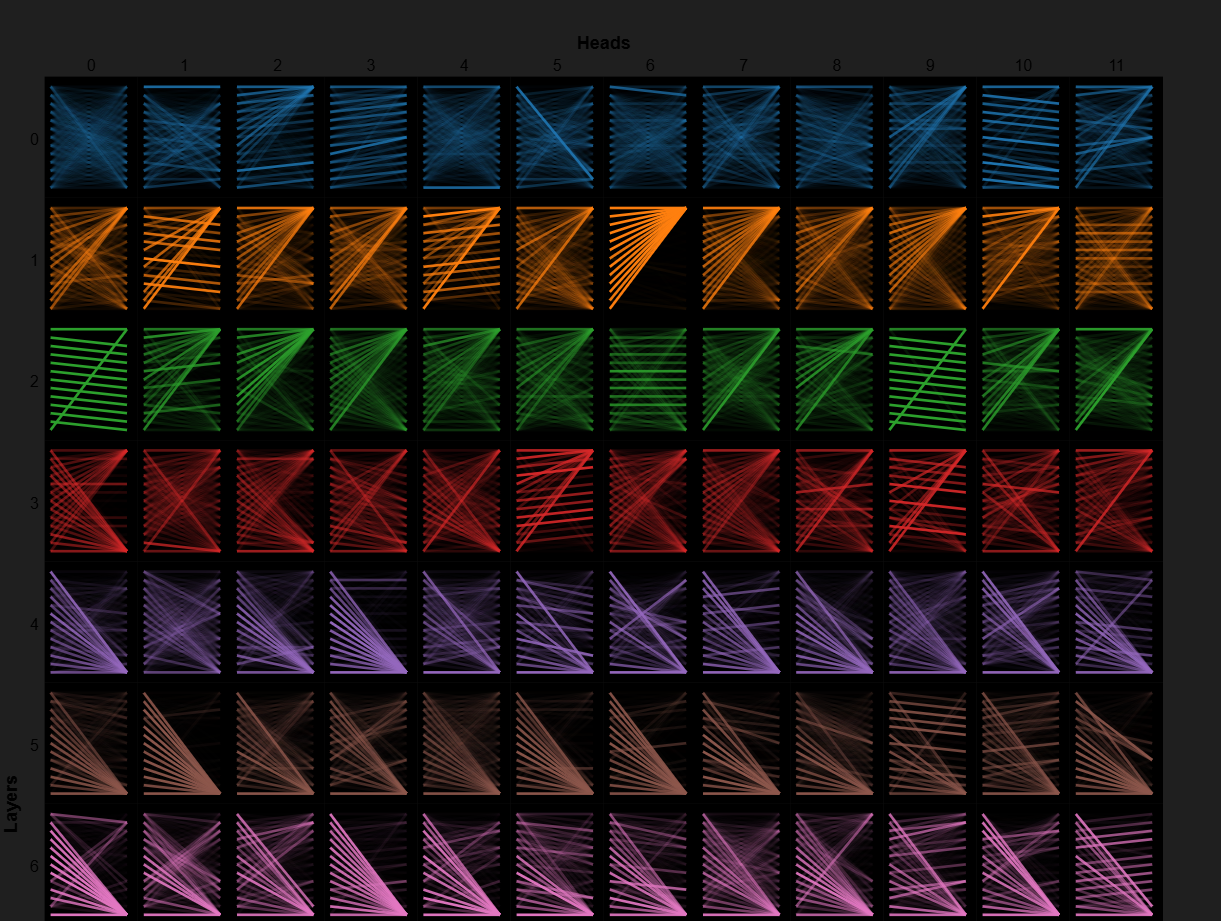

# Part 3 – Head Investigation (25 Marks)

Complete this table.

| Layer | Head | Behavior | Evidence | Did it match your expectation? |
|-------|------|----------|----------|--------------------------------|
|2 |4 | Positional |Nearby words attend to each other. |Yes |
|8 |2 | Long-range |"boy" attends to "friend". |Yes |
|11 |1 | Special Token / CLS |Many tokens attend to [CLS]. |Yes |

After the table, answer:

- Why is this head interesting?
1. It shows how words are connected.
- Which tokens communicate?
    - boy ↔ friend
    - not ↔ like
    - baked ↔ mother
- What engineering insight does it provide?
3. Attention helps us see which words are related.


# Part 4 – Expectations vs Reality (15 Marks)

| Sentence | Expected | Observed | Match? |
|-----------|----------|----------|--------|
| 1 | boy → friend | Yes | Yes |
| 2 | he → Ali/Omar | Partial | Partial |
| 3 | not → like | Yes | Yes |
| 4 | baked → mother | Yes | Yes |
| 5 | Anyone | Yes | Yes |

Write a short discussion (100–150 words) explaining any surprising findings.


# Part 5 – Engineering Reflection (20 Marks)

Imagine your manager asks:

> **Should engineers use attention maps for debugging production models?**

Write **300–400 words** addressing:

1. What attention maps reveal well.
2. Their limitations.
3. Why attention is **not** a complete explanation.
4. When engineers should use them.
5. Your final recommendation with a confidence level.

*Attention maps are useful because they show which words the model looks at while processing a sentence. This helps us understand some relationships between words, such as subjects, verbs, or negation. They can also help find strange behavior when debugging a model.*

*However, attention maps have limitations. A word with high attention is not always the reason for the final prediction. Different attention heads may focus on different parts of the sentence, and some important information is processed outside the attention layers. Because of this, attention is not a complete explanation of how BERT works.*

*Engineers should use attention maps to explore model behavior and understand patterns, but they should not depend on them alone. It is better to combine attention maps with testing, evaluation, and other explainability methods. This gives a better understanding of the model's decisions.*

*My recommendation is to use attention maps as a helpful debugging tool, not as proof of why the model made a prediction. Confidence level: Medium (80%).*


# ⭐ Bonus (+10)

Try one of the following:

- Winograd sentence
- Sarcasm
- Idiom
- Arabic sentence
- Code-mixed sentence
- Emoji sentence

Discuss whether attention changed.


# ✅ Submission Checklist

- [ ] Five original sentences
- [ ] Predictions written before experiments
- [ ] BertViz screenshots included
- [ ] Three head behaviors documented
- [ ] Expectations vs Reality completed
- [ ] Engineering reflection completed
- [ ] Notebook executed from start to finish
